# Create LLM Evaluation Figure

In [87]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hiatus.config import metrics, metrics_dir, plots_dir

In [88]:
baseline_metrics_dir = "/gscratch/ifml1/hiatus/metrics/"
plots_dir.mkdir(parents=True, exist_ok=True)

In [89]:
mpl.rcParams.update({
	"lines.linewidth": 2.0,
	"xtick.labelsize": 20,
	"ytick.labelsize": 20,
	"axes.labelsize": 20,
	"legend.fontsize": 20,
	"axes.titlesize": 20,
	"font.family": "sans-serif",
	"pdf.fonttype": 42,
	"ps.fonttype": 42,
	"figure.labelsize": 20,
	"text.usetex": False,
})

In [90]:
from collections import OrderedDict

def load_results(paths, sense_scores=True) -> pd.DataFrame:
    results = pd.DataFrame()
    for path in paths:
        if sense_scores:
            data = pd.read_json(path, lines=True)
        else:
            data = pd.read_csv(path)

        results = pd.concat([results, data])
    return results


def infer_experiment_id(model_name, cfg):
    if cfg.get("experiment_id"):
        return str(cfg["experiment_id"])

    style_n = cfg.get("n_styles_to_change")
    suffix = f"-{style_n}" if style_n is not None else ""
    if suffix and str(model_name).endswith(suffix):
        return str(model_name)[: -len(suffix)]

    return str(cfg.get("label", model_name))


def build_mean_metrics_df(metrics_path, columns):
    df = pd.DataFrame()
    for model_name, cfg in metrics_path.items():
        if not cfg["report"]:
            continue

        results = load_results(cfg["sense_scores"])
        results = results.drop(columns="documentID", errors="ignore")
        results = results[columns]

        for col in results.columns:
            if col in metrics:
                results[col] = results[col] * metrics[col]["scale"]

        results = results.mean(axis=0).to_frame(name="mean")
        results.index = [
            metrics[key]["title"] if key in metrics else key
            for key in results.index
        ]
        results = results.T
        df = pd.concat([df, results])

    return df


def build_privacy_df(metrics_path):
    df2 = pd.DataFrame()
    for model_name, cfg in metrics_path.items():
        if not cfg["report"]:
            continue

        results = load_results(cfg["privacy_consistency"], sense_scores=False)
        results = results.iloc[:, :1]
        results = results.mean(axis=0).to_frame(name="mean")
        results.index = [
            metrics[key]["title"] if key in metrics else key
            for key in results.index
        ]
        results = results.T
        df2 = pd.concat([df2, results])

    return df2


def build_plot_layout(metrics_path, width=0.4, intra_group_gap=0.12, language_gap=0.6):
    models = [m for m, cfg in metrics_path.items() if cfg["report"]]

    lang_groups = OrderedDict()
    for m in models:
        lang = metrics_path[m]["language"]
        if lang not in lang_groups:
            lang_groups[lang] = []
        lang_groups[lang].append(m)

    x_positions = []
    plot_models = []
    group_centers = {}
    tick_positions = []
    tick_labels = []

    cursor = 0.0
    lang_items = list(lang_groups.items())

    for lang_idx, (lang, lang_models) in enumerate(lang_items):
        lang_x = []
        exp_order = []

        for m in lang_models:
            exp_id = infer_experiment_id(m, metrics_path[m])
            if exp_id not in exp_order:
                exp_order.append(exp_id)

        for exp_idx, exp_id in enumerate(exp_order):
            exp_models = [
                m for m in lang_models
                if infer_experiment_id(m, metrics_path[m]) == exp_id
            ]
            exp_models = sorted(
                exp_models,
                key=lambda m: metrics_path[m]["n_styles_to_change"],
            )

            exp_x = []
            for m in exp_models:
                x_positions.append(cursor)
                plot_models.append(m)
                lang_x.append(cursor)
                exp_x.append(cursor)
                cursor += width

            style2_idx = None
            for idx, m in enumerate(exp_models):
                if metrics_path[m]["n_styles_to_change"] == 2:
                    style2_idx = idx
                    break

            if style2_idx is not None:
                tick_x = exp_x[style2_idx]
            else:
                tick_x = float(np.mean(exp_x))

            tick_positions.append(tick_x)
            tick_labels.append(metrics_path[exp_models[0]]["label"])

            if exp_idx < len(exp_order) - 1:
                cursor += intra_group_gap

        if lang_x:
            group_centers[lang] = float(np.mean(lang_x))

        if lang_idx < len(lang_items) - 1:
            cursor += language_gap

    x = np.array(x_positions)
    model_to_index = {m: i for i, m in enumerate(models)}
    plot_indices = [model_to_index[m] for m in plot_models]

    return {
        "models": models,
        "plot_models": plot_models,
        "plot_indices": plot_indices,
        "x": x,
        "width": width,
        "tick_positions": tick_positions,
        "tick_labels": tick_labels,
        "group_centers": group_centers,
    }


def plot_metric_block(df, metrics_path, layout, nrows, ncols, figsize, output_filename, tick_rotation=70):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey="row", sharex="col")
    axes_flat = np.array(axes).reshape(-1)

    colors = [metrics_path[m]["color"] for m in layout["plot_models"]]

    for i, ax in enumerate(axes_flat):
        ax.grid(axis="y", which="major", color="gray", alpha=0.5, linestyle="dashed", zorder=-1)
        ax.set_axisbelow(True)

        ax.bar(
            layout["x"],
            df.iloc[layout["plot_indices"], i],
            layout["width"],
            color=colors,
            edgecolor="black",
            linewidth=1.0,
            zorder=1,
        )

        ax.set_title(df.columns[i])
        ax.set_ylim(0, 1.05)
        ax.set_xticks(layout["tick_positions"])
        ax.set_xticklabels(layout["tick_labels"], rotation=tick_rotation, color="grey", ha="right")

    plt.subplots_adjust(wspace=0.05)
    path = Path(plots_dir, output_filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path.as_posix(), bbox_inches="tight")

In [91]:
use_old_ar_model = True
ar_sense_code = "ar_old_model" if use_old_ar_model else "ar"

metrics_path = {
    # Baselines, reported in Dec
	"prompt-remix-zh0-1": {
		"language": "zh",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*1_ta3_results.csv")],
		"color": ("#027100", 0.2),
		"label": "PromptRemix-ZH0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-zh0-2": {
		"language": "zh",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*2_ta3_results.csv")],
		"color": ("#027100", 0.5),
		"label": "PromptRemix-ZH0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-zh0-3": {
		"language": "zh",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "zh").glob("*3_ta3_results.csv")],
		"color": ("#027100", 0.8),
		"label": "PromptRemix-ZH0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar0-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "PromptRemix-AR0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar0-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "PromptRemix-AR0",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar0-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar0-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "PromptRemix-AR0",
		"hatch": False,
		"report": True,
	},
    # "prompt-remix-ar20-1": {
	# 	"language": "ar",
	# 	"n_styles_to_change": 1,
	# 	"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-1_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-1_ta3_results.csv")],
	# 	"color": ("#DF6800", 0.2),
	# 	"label": "PromptRemix-AR20",
	# 	"hatch": False,
	# 	"report": True,
	# },
	# "prompt-remix-ar20-2": {
	# 	"language": "ar",
	# 	"n_styles_to_change": 2,
	# 	"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-2_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-2_ta3_results.csv")],
	# 	"color": ("#DF6800", 0.5),
	# 	"label": "PromptRemix-AR20",
	# 	"hatch": False,
	# 	"report": True,
	# },
	# "prompt-remix-ar20-3": {
	# 	"language": "ar",
	# 	"n_styles_to_change": 3,
	# 	"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-3_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ar").glob("*ar20-3_ta3_results.csv")],
	# 	"color": ("#DF6800", 0.8),
	# 	"label": "PromptRemix-AR0-3",
	# 	"hatch": False,
	# 	"report": True,
	# },
	"prompt-remix-enF-1": {
		"language": "en",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*1_ta3_results.csv")],
		"color": ("#004D80", 0.2),
		"label": "PromptRemix-ENF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-enF-2": {
		"language": "en",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*2_ta3_results.csv")],
		"color": ("#004D80", 0.5),
		"label": "PromptRemix-ENF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-enF-3": {
		"language": "en",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "en").glob("*3_ta3_results.csv")],
		"color": ("#004D80", 0.8),
		"label": "PromptRemix-ENF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-ruF-1": {
		"language": "ru",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*1_ta3_results.csv")],
		"color": ("#800000", 0.2),
		"label": "PromptRemix-RUF",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-ruF-2": {
		"language": "ru",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*2_ta3_results.csv")],
		"color": ("#800000", 0.5),
		"label": "PromptRemix-RUF-2",
        "hatch": False,
		"report": True,
	},
	"prompt-remix-ruF-3": {
		"language": "ru",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(baseline_metrics_dir, "ru").glob("*3_ta3_results.csv")],
		"color": ("#800000", 0.8),
		"label": "PromptRemix-RUF",
        "hatch": False,
		"report": True,
	},

	# AR Baseline
    "prompt-remix-ar20-baseline-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-baseline-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-baseline-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "Qwen2.5",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar20-baseline-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-baseline-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-baseline-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "Qwen2.5",
		"hatch": False,
		"report": True,
	},
	"prompt-remix-ar20-baseline-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-baseline-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-baseline-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "Qwen2.5",
		"hatch": False,
		"report": True,
	},

	# # # Qwen 3.5 metrics
    "prompt-remix-zh0-qwen3.5-1": {
		"language": "zh",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-1_ta3_results.csv")],
		"color": ("#027100", 0.2),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-qwen3.5-2": {
		"language": "zh",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-2_ta3_results.csv")],
		"color": ("#027100", 0.5),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-zh0-qwen3.5-3": {
		"language": "zh",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-3_ta3_results.csv")],
		"color": ("#027100", 0.8),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-1": {
		"language": "ar",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-1_ta3_results.csv")],
		"color": ("#DF6800", 0.2),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-2": {
		"language": "ar",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-2_ta3_results.csv")],
		"color": ("#DF6800", 0.5),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ar0-qwen3.5-3": {
		"language": "ar",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-3_ta3_results.csv")],
		"color": ("#DF6800", 0.8),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-1": {
		"language": "en",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-1_ta3_results.csv")],
		"color": ("#004D80", 0.2),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-2": {
		"language": "en",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-2_ta3_results.csv")],
		"color": ("#004D80", 0.5),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-enF-qwen3.5-3": {
		"language": "en",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-3_ta3_results.csv")],
		"color": ("#004D80", 0.8),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-1": {
		"language": "ru",
		"n_styles_to_change": 1,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-1_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-1_ta3_results.csv")],
		"color": ("#800000", 0.2),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-2": {
		"language": "ru",
		"n_styles_to_change": 2,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-2_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-2_ta3_results.csv")],
		"color": ("#800000", 0.5),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    "prompt-remix-ru-qwen3.5-3": {
		"language": "ru",
		"n_styles_to_change": 3,
		"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-3_llm.jsonl")],
		"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-3_ta3_results.csv")],
		"color": ("#800000", 0.8),
		"label": "Qwen3.5",
		"hatch": False,
		"report": True,
	},
    
	# # Style transfer metrics
    # "prompt-remix-zh0-transfer-qwen3_5-1": {
	# 	"language": "zh",
	# 	"n_styles_to_change": 1,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-1_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-1_ta3_results.csv")],
	# 	"color": ("#027100", 0.2),
	# 	"label": "Qwen3.5 Transfer",
	# 	"hatch": False,
	# 	"report": True,
	# },
    # "prompt-remix-zh0-transfer-qwen3_5-2": {
	# 	"language": "zh",
	# 	"n_styles_to_change": 2,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-2_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-2_ta3_results.csv")],
	# 	"color": ("#027100", 0.5),
	# 	"label": "Qwen3.5 Transfer",
	# 	"hatch": False,
	# 	"report": True,
	# },
    # "prompt-remix-zh0-transfer-qwen3_5-3": {
	# 	"language": "zh",
	# 	"n_styles_to_change": 3,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-3_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-transfer-qwen3_5-3_ta3_results.csv")],
	# 	"color": ("#027100", 0.8),
	# 	"label": "Qwen3.5 Transfer",
	# 	"hatch": False,
	# 	"report": True,
	# },
    
	# Constrained Decoding Metrics
    # "prompt-remix-zh0-qwen3.5-constr-1": {
	# 	"language": "zh",
	# 	"n_styles_to_change": 1,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-1_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-1_ta3_results.csv")],
	# 	"color": ("#027100", 0.2),
	# 	"label": "PromptRemix-ZH0-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-zh0-qwen3.5-constr-2": {
	# 	"language": "zh",
	# 	"n_styles_to_change": 2,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-2_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-2_ta3_results.csv")],
	# 	"color": ("#027100", 0.5),
	# 	"label": "PromptRemix-ZH0-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-zh0-qwen3.5-constr-3": {
	# 	"language": "zh",
	# 	"n_styles_to_change": 3,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-3_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "zh").glob("*zh0-qwen3.5-constr-3_ta3_results.csv")],
	# 	"color": ("#027100", 0.8),
	# 	"label": "PromptRemix-ZH0-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-ar0-qwen3.5-constr-1": {
	# 	"language": "ar",
	# 	"n_styles_to_change": 1,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-constr-1_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-constr-1_ta3_results.csv")],
	# 	"color": ("#DF6800", 0.2),
	# 	"label": "PromptRemix-AR22-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-ar0-qwen3.5-constr-2": {
	# 	"language": "ar",
	# 	"n_styles_to_change": 2,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-constr-2_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-constr-2_ta3_results.csv")],
	# 	"color": ("#DF6800", 0.5),
	# 	"label": "PromptRemix-AR22-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-ar0-qwen3.5-constr-3": {
	# 	"language": "ar",
	# 	"n_styles_to_change": 3,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, ar_sense_code).glob("*ar22-qwen3.5-constr-3_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ar").glob("*ar22-qwen3.5-constr-3_ta3_results.csv")],
	# 	"color": ("#DF6800", 0.8),
	# 	"label": "PromptRemix-AR22-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-enF-qwen3.5-constr-1": {
	# 	"language": "en",
	# 	"n_styles_to_change": 1,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-1_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-1_ta3_results.csv")],
	# 	"color": ("#004D80", 0.2),
	# 	"label": "PromptRemix-ENF-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-enF-qwen3.5-constr-2": {
	# 	"language": "en",
	# 	"n_styles_to_change": 2,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-2_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-2_ta3_results.csv")],
	# 	"color": ("#004D80", 0.5),
	# 	"label": "PromptRemix-ENF-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-enF-qwen3.5-constr-3": {
	# 	"language": "en",
	# 	"n_styles_to_change": 3,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-3_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "en").glob("*enF-qwen3.5-constr-3_ta3_results.csv")],
	# 	"color": ("#004D80", 0.8),
	# 	"label": "PromptRemix-ENF-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-ru-qwen3.5-constr-1": {
	# 	"language": "ru",
	# 	"n_styles_to_change": 1,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-1_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-1_ta3_results.csv")],
	# 	"color": ("#800000", 0.2),
	# 	"label": "PromptRemix-RU-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-ru-qwen3.5-constr-2": {
	# 	"language": "ru",
	# 	"n_styles_to_change": 2,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-2_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-2_ta3_results.csv")],
	# 	"color": ("#800000", 0.5),
	# 	"label": "PromptRemix-RU-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
    # "prompt-remix-ru-qwen3.5-constr-3": {
	# 	"language": "ru",
	# 	"n_styles_to_change": 3,
	# 	"sense_scores": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-3_llm.jsonl")],
	# 	"privacy_consistency": [p.as_posix() for p in Path(metrics_dir, "ru").glob("*ru-qwen3.5-constr-3_ta3_results.csv")],
	# 	"color": ("#800000", 0.8),
	# 	"label": "PromptRemix-RU-Qwen3.5-Constrained",
	# 	"hatch": False,
	# 	"report": False,
	# },
}

## Sense Scores

In [92]:
columns = list(metrics.keys())[:6]

df = build_mean_metrics_df(metrics_path, columns)

In [93]:
layout = build_plot_layout(
    metrics_path,
    width=0.4,
    intra_group_gap=0.12,
    language_gap=0.6,
)

models = layout["models"]
plot_models = layout["plot_models"]
plot_indices = layout["plot_indices"]
x = layout["x"]
width = layout["width"]
set_tick_positions = layout["tick_positions"]
set_tick_labels = layout["tick_labels"]
group_centers = layout["group_centers"]

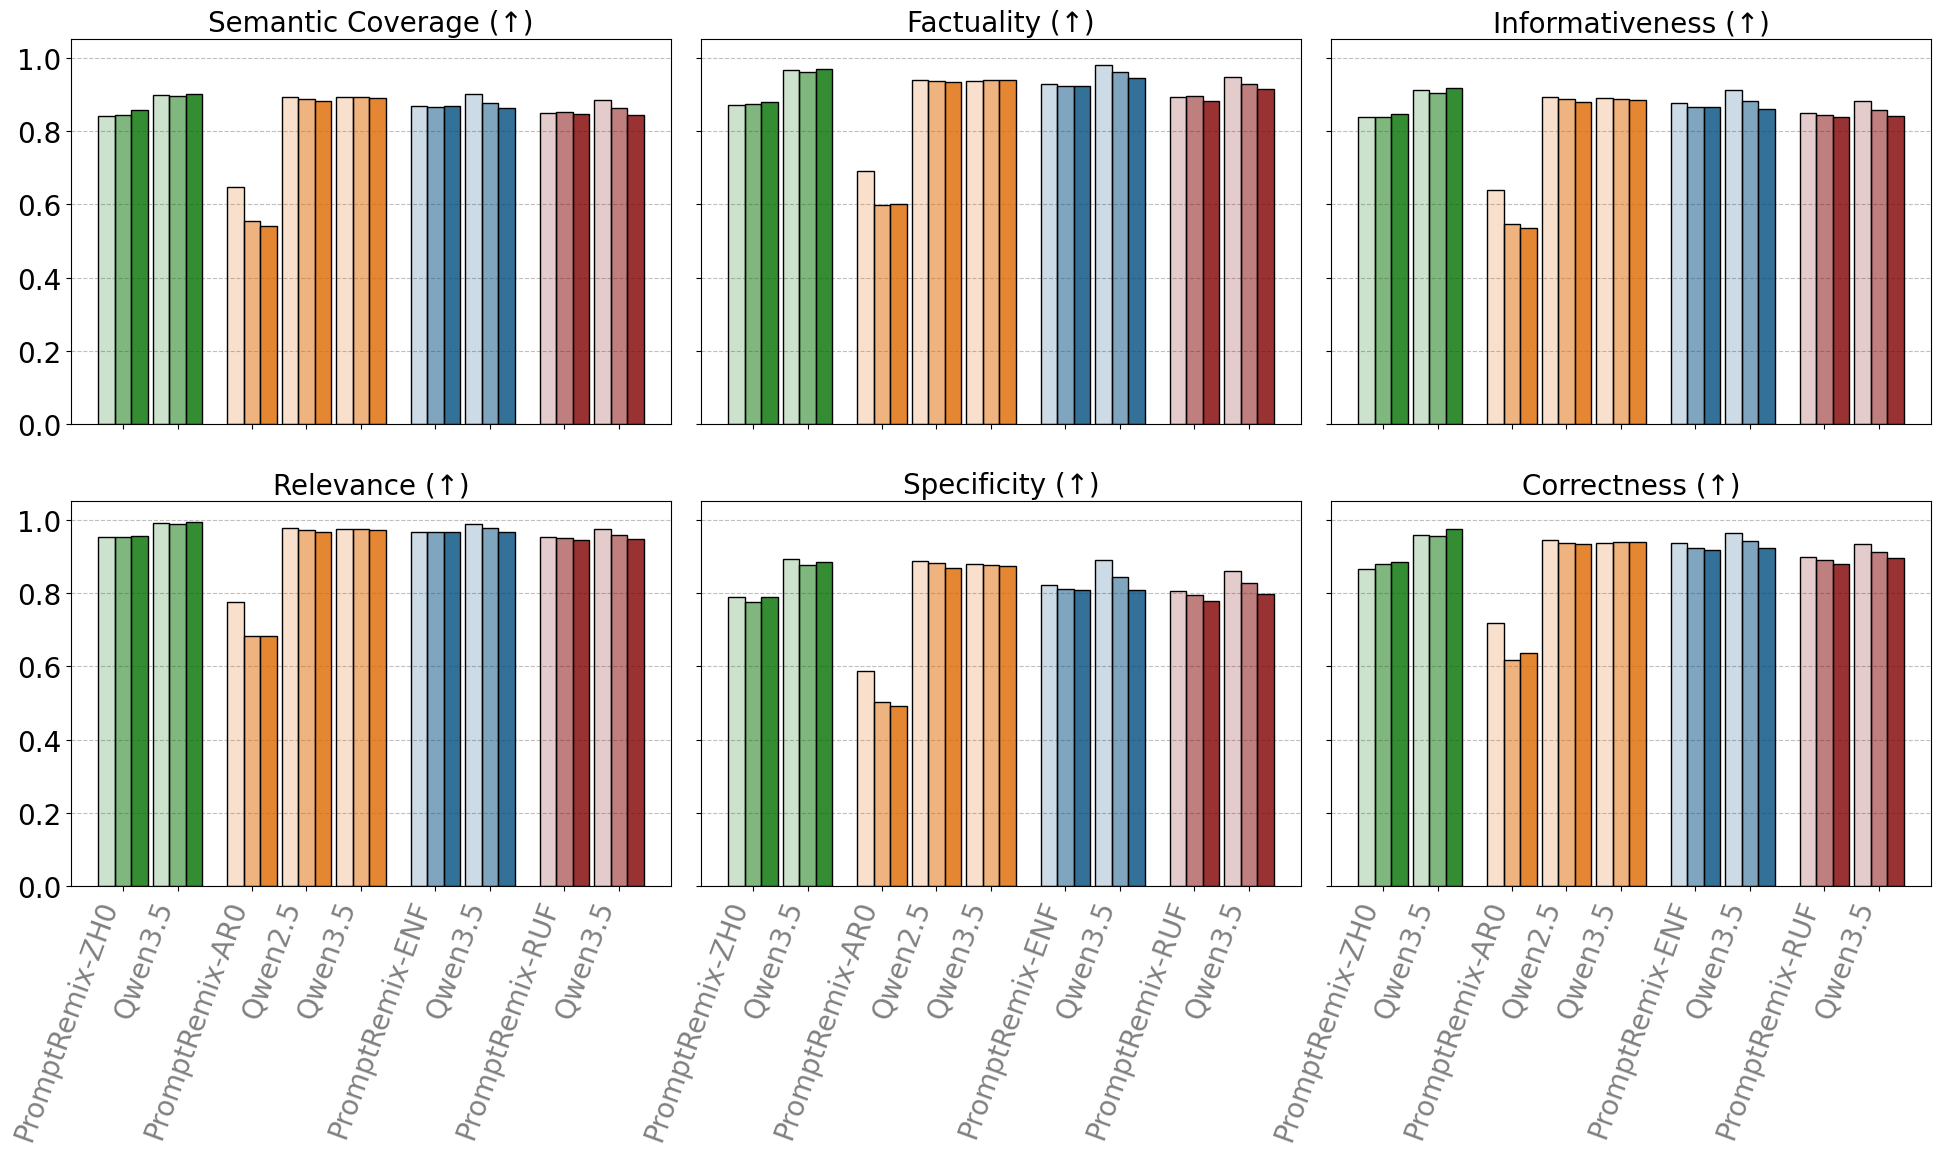

In [94]:
scale = 3
plot_metric_block(
    df=df,
    metrics_path=metrics_path,
    layout=layout,
    nrows=2,
    ncols=3,
    figsize=(24, 11),
    output_filename="prompt-remix-11.pdf",
    tick_rotation=70,
)

In [95]:
columns = list(metrics.keys())[6:12]

df = build_mean_metrics_df(metrics_path, columns)

In [96]:
layout = build_plot_layout(
    metrics_path,
    width=0.4,
    intra_group_gap=0.12,
    language_gap=0.6,
)

models = layout["models"]
plot_models = layout["plot_models"]
plot_indices = layout["plot_indices"]
x = layout["x"]
width = layout["width"]
set_tick_positions = layout["tick_positions"]
set_tick_labels = layout["tick_labels"]
group_centers = layout["group_centers"]

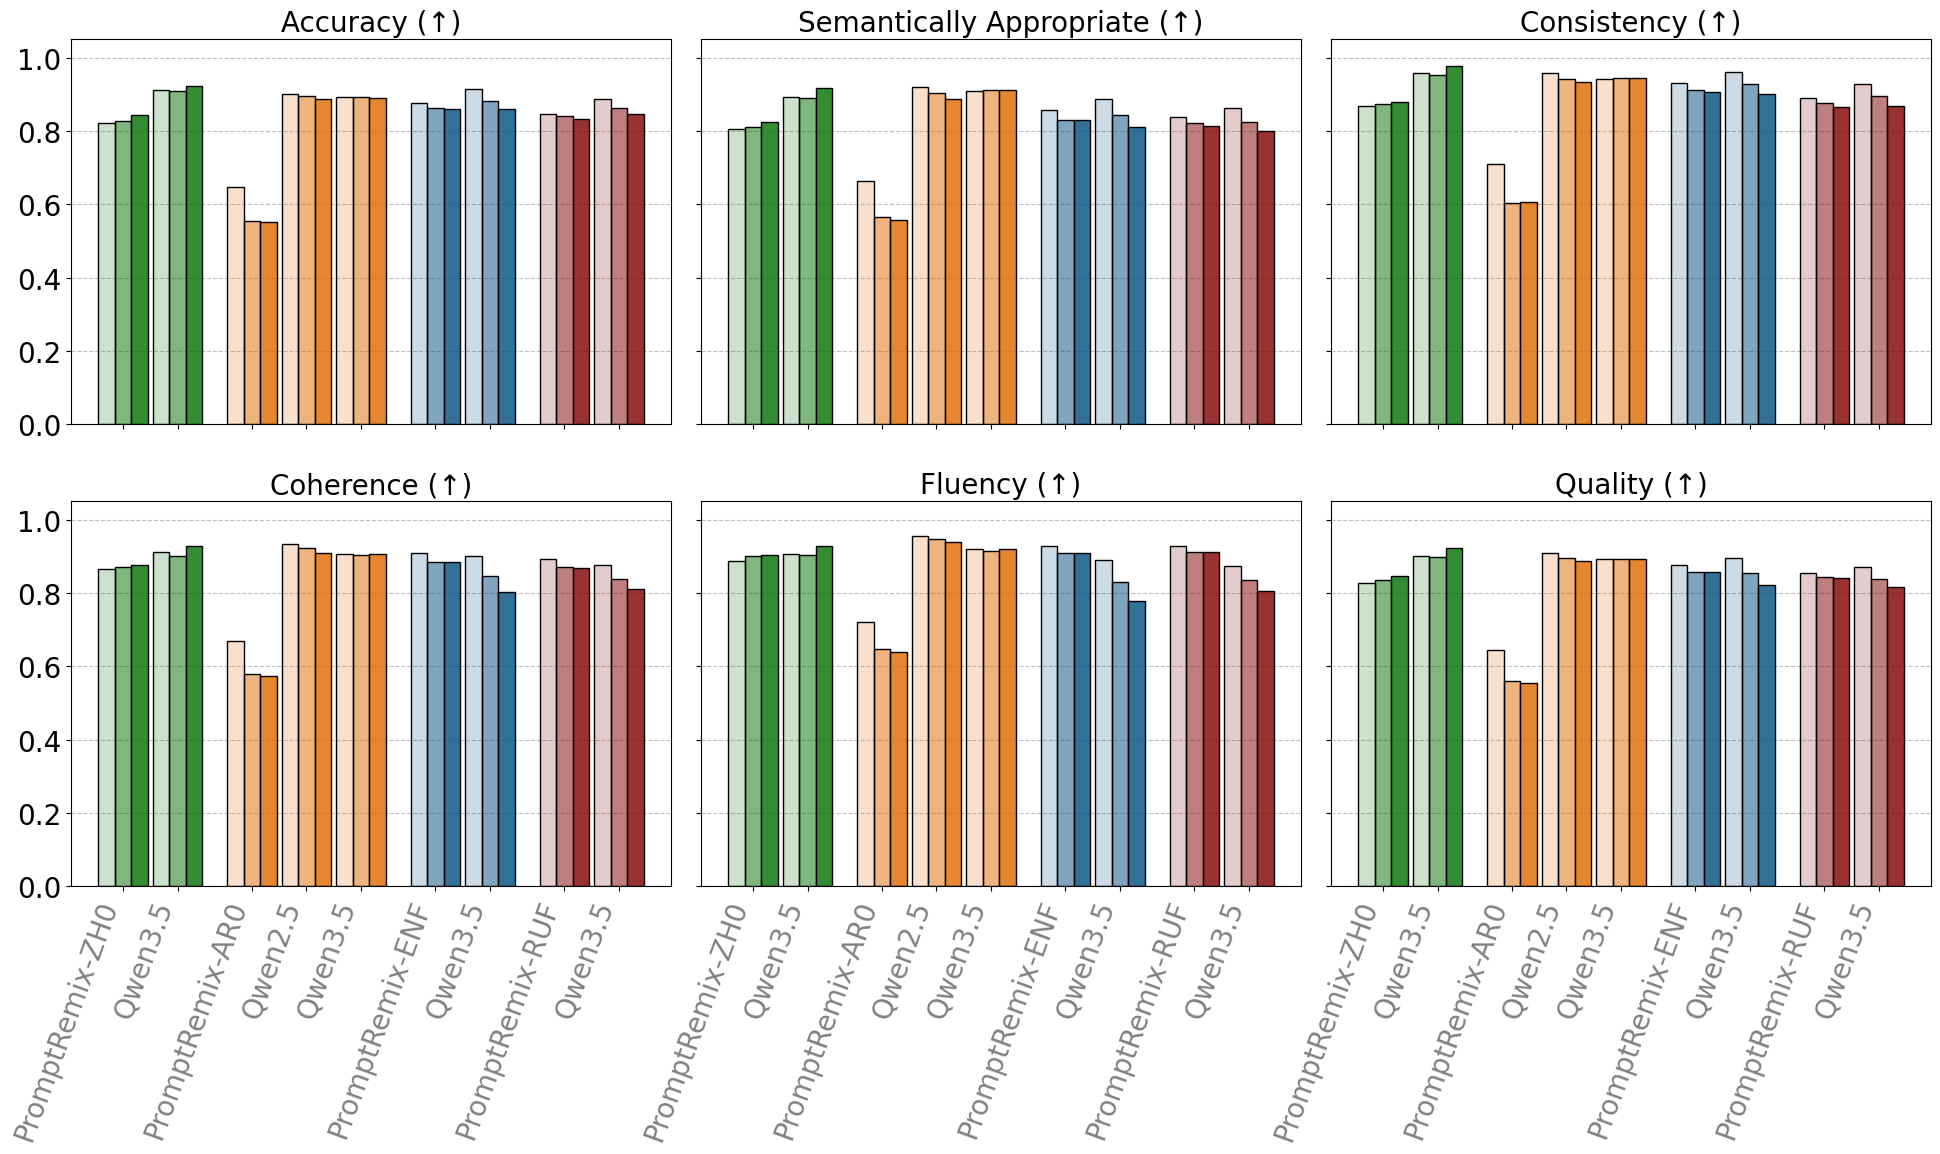

In [97]:
scale = 3
plot_metric_block(
    df=df,
    metrics_path=metrics_path,
    layout=layout,
    nrows=2,
    ncols=3,
    figsize=(24, 11),
    output_filename="prompt-remix-12.pdf",
    tick_rotation=70,
)

## Privacy + Remaining Sense Scores

In [98]:
df2 = build_privacy_df(metrics_path)

In [99]:
columns = list(metrics.keys())[12:14]

df = build_mean_metrics_df(metrics_path, columns)

In [100]:
df.columns.to_list()

['Understandability (↑)', 'Cosine Similarity (↑)']

In [101]:
df["Delta Equal Error Rate (↑)"] = df2
df = df[["Delta Equal Error Rate (↑)", *df.columns.to_list()]]

In [102]:
layout = build_plot_layout(
    metrics_path,
    width=0.4,
    intra_group_gap=0.12,
    language_gap=0.6,
)

models = layout["models"]
plot_models = layout["plot_models"]
plot_indices = layout["plot_indices"]
x = layout["x"]
width = layout["width"]
set_tick_positions = layout["tick_positions"]
set_tick_labels = layout["tick_labels"]
group_centers = layout["group_centers"]

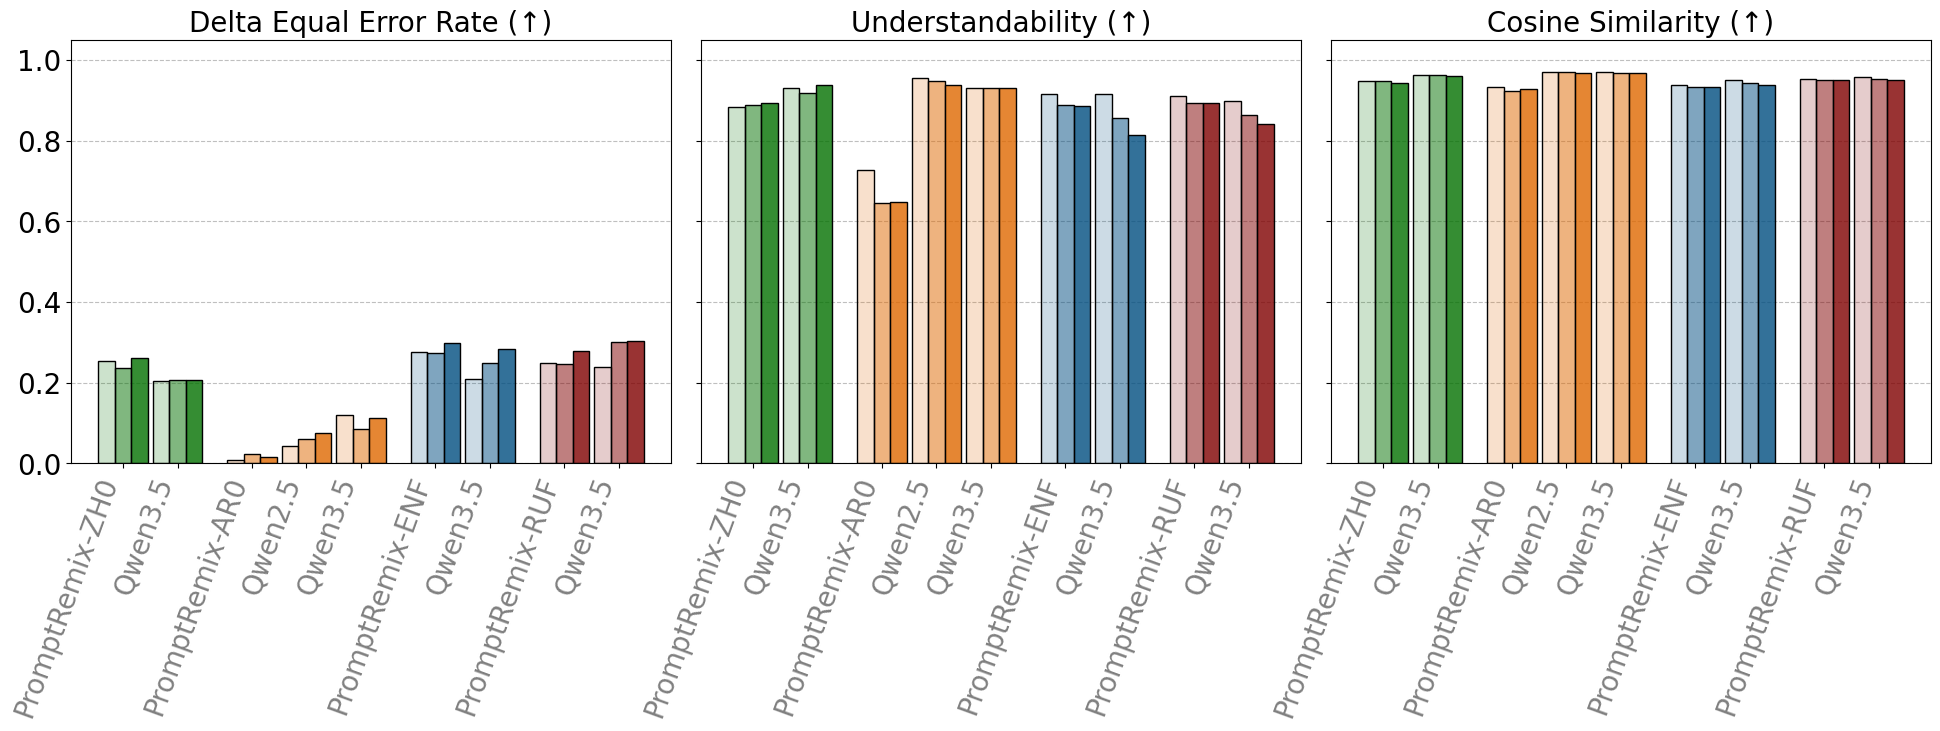

In [103]:
scale = 3
plot_metric_block(
    df=df,
    metrics_path=metrics_path,
    layout=layout,
    nrows=1,
    ncols=3,
    figsize=(24, 5.5),
    output_filename="prompt-remix-13.pdf",
    tick_rotation=70,
)

## Average Metrics Table Export

In [104]:
from matplotlib.backends.backend_pdf import PdfPages

def infer_available_sense_columns(metrics_path):
    expected_cols = list(metrics.keys())
    for _, cfg in metrics_path.items():
        if not cfg["report"]:
            continue
        sample = load_results(cfg["sense_scores"]).drop(columns="documentID", errors="ignore")
        return [c for c in expected_cols if c in sample.columns]
    return expected_cols


def build_average_metrics_table(metrics_path):
    sense_columns = infer_available_sense_columns(metrics_path)
    sense_df = build_mean_metrics_df(metrics_path, sense_columns)
    privacy_df = build_privacy_df(metrics_path)

    model_keys = [m for m, cfg in metrics_path.items() if cfg["report"]]

    sense_df = sense_df.reset_index(drop=True)
    privacy_col = privacy_df.columns[0]
    privacy_series = privacy_df.iloc[:, 0].reset_index(drop=True)
    sense_df.insert(0, privacy_col, privacy_series)

    meta_df = pd.DataFrame(
        {
            "Model ID": model_keys,
            "System": [metrics_path[m]["label"] for m in model_keys],
            "Language": [metrics_path[m]["language"] for m in model_keys],
            "Styles Changed": [metrics_path[m]["n_styles_to_change"] for m in model_keys],
        }
    )

    table_df = pd.concat([meta_df, sense_df], axis=1)

    layout = build_plot_layout(
        metrics_path,
        width=0.4,
        intra_group_gap=0.12,
        language_gap=0.6,
    )
    order = pd.Categorical(
        table_df["Model ID"],
        categories=layout["plot_models"],
        ordered=True,
    )
    table_df = table_df.assign(_order=order).sort_values("_order").drop(columns="_order")
    table_df = table_df.reset_index(drop=True)
    return table_df


def save_table_outputs(table_df, csv_filename, pdf_filename, decimals=3, rows_per_page=12):
    csv_path = Path(plots_dir, csv_filename)
    pdf_path = Path(plots_dir, pdf_filename)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    pdf_path.parent.mkdir(parents=True, exist_ok=True)

    out_df = table_df.copy()
    meta_cols = {"Model ID", "System", "Language", "Styles Changed"}
    metric_cols = [c for c in out_df.columns if c not in meta_cols]
    out_df[metric_cols] = out_df[metric_cols].round(decimals)

    out_df.to_csv(csv_path, index=False)

    with PdfPages(pdf_path) as pdf:
        for start in range(0, len(out_df), rows_per_page):
            page_df = out_df.iloc[start : start + rows_per_page]
            fig_height = max(3.0, 1.1 + 0.45 * len(page_df))
            fig, ax = plt.subplots(figsize=(26, fig_height))
            ax.axis("off")

            table = ax.table(
                cellText=page_df.values,
                colLabels=page_df.columns,
                loc="center",
                cellLoc="center",
            )
            table.auto_set_font_size(False)
            table.set_fontsize(8)
            table.scale(1, 1.35)

            ax.set_title("Average metrics used in bar charts", fontsize=14, pad=8)
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    return csv_path, pdf_path, out_df


average_metrics_df = build_average_metrics_table(metrics_path)
csv_path, pdf_path, average_metrics_df_rounded = save_table_outputs(
    average_metrics_df,
    csv_filename="prompt-remix-average-metrics.csv",
    pdf_filename="prompt-remix-average-metrics.pdf",
    decimals=3,
    rows_per_page=12,
)

average_metrics_df_rounded.head(), csv_path.as_posix(), pdf_path.as_posix()

(                     Model ID           System Language  Styles Changed  \
 0          prompt-remix-zh0-1  PromptRemix-ZH0       zh               1   
 1          prompt-remix-zh0-2  PromptRemix-ZH0       zh               2   
 2          prompt-remix-zh0-3  PromptRemix-ZH0       zh               3   
 3  prompt-remix-zh0-qwen3.5-1          Qwen3.5       zh               1   
 4  prompt-remix-zh0-qwen3.5-2          Qwen3.5       zh               2   
 
    Delta Equal Error Rate  Semantic Coverage (↑)  Factuality (↑)  \
 0                   0.254                  0.840           0.871   
 1                   0.238                  0.844           0.875   
 2                   0.261                  0.857           0.878   
 3                   0.204                  0.899           0.968   
 4                   0.207                  0.895           0.963   
 
    Informativeness (↑)  Relevance (↑)  Specificity (↑)  Correctness (↑)  \
 0                0.838          0.953            